# 실습 세트 2. 조건부확률 분석을 활용한 합리적인 의사결정 정량화

## 1. CSV 파일 다운로드

먼저 아래 CSV 파일을 다운로드한 뒤, 노트북 파일과 같은 폴더에 둡니다.

파일명:

`semicond_proba.csv`

이 데이터는 공장 A, B, C에서 생산된 반도체 제품의 생산 조건과 불량 여부를 담고 있는 가상 데이터입니다.

---

## 2. 문제 상황 설명

반도체 생산 기업이 공장 A, B, C에서 제품을 생산하고 있습니다.

각 공장은 서로 다른 제품 유형과 생산 조건을 가지고 있으며, 제품별로 정상/불량 여부가 기록되어 있습니다.

이번 실습의 목표는 조건부확률을 사용하여 특정 조건에서의 불량률을 계산하고, 이를 바탕으로 합리적인 생산 배정 의사결정을 내리는 것입니다.

예를 들어 전체 불량률은 다음과 같이 표현할 수 있습니다.

`P(불량)`

공장 A에서 생산된 제품 중 불량일 확률은 다음과 같이 표현할 수 있습니다.

`P(불량 | 공장=A)`

이처럼 특정 조건이 주어졌을 때 어떤 사건이 발생할 확률을 조건부확률이라고 합니다.

### 데이터 컬럼 설명

| 컬럼명 | 설명 |
|---|---|
| Product_ID | 제품 ID |
| Factory | 생산 공장 |
| Line | 생산 라인 |
| Shift | 주간/야간 교대조 |
| Product_Type | 제품 유형 |
| Process_Mode | 일반 생산/고속 생산 모드 |
| Defect | 정상/불량 여부 |

`Defect` 컬럼의 의미는 다음과 같습니다.

- `Defect = 0`: 정상
- `Defect = 1`: 불량


### 문제

#### 문제 1. 데이터 기본 확인

CSV 파일을 불러온 뒤 다음 내용을 확인하세요.

- 상위 5개 행
- 데이터 크기
- 컬럼별 자료형
- 결측치 개수
- 전체 불량률


In [2]:
import pandas as pd

df = pd.read_csv("semicond_proba.csv")
df['Defect'].mean() * 100

np.float64(6.666666666666667)

- **<font color="red">AI 코드</font>**

In [12]:
# 전체 불량률 계산
defect_rate = df["Defect"].mean() * 100

print(f"전체 불량률: {defect_rate:.2f}%")

전체 불량률: 6.67%


#### 문제 2. 공장별 불량률 계산

공장별(Factory)로 다음 값을 계산하세요.

- 생산 건수: 그룹바이 후 size() 활용
- 불량 건수: 그룹바이 후 Defect 컬럼 선택 후 sum()
- 불량률: 그룹바이 후 Defect 컬럼 선택 후 mean()

In [3]:
dfg = df.groupby('Factory')
dfg.size()

Factory
A    1298
B    1210
C    1092
dtype: int64

In [4]:
dfg['Defect'].sum()

Factory
A    62
B    89
C    89
Name: Defect, dtype: int64

In [5]:
dfg['Defect'].mean()

Factory
A    0.047766
B    0.073554
C    0.081502
Name: Defect, dtype: float64

#### 문제 3. 공장별 불량률 시각화

seaborn의 `barplot()`을 사용해 공장별 불량률을 시각화하세요.


<Axes: xlabel='Factory', ylabel='Defect'>

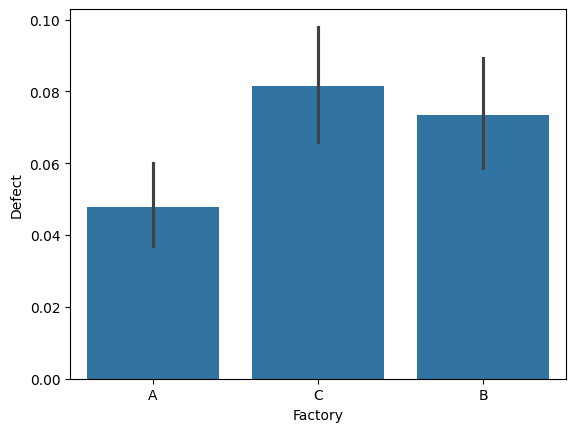

In [6]:
import seaborn as sns

sns.barplot(df, x='Factory', y='Defect')

- **<font color="red">AI 코드</font>**


  Factory    Defect
0       A  4.776579
1       B  7.355372
2       C  8.150183


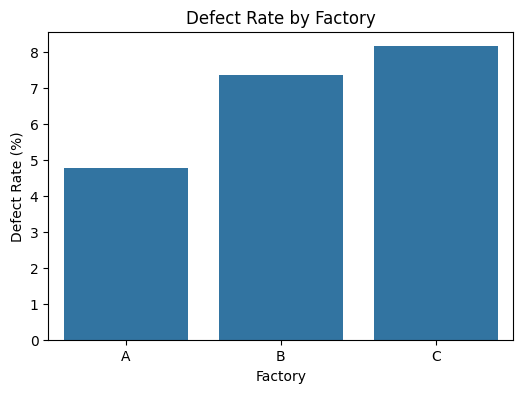

In [14]:
import matplotlib.pyplot as plt

# -----------------------------------
# 공장별 불량률 계산
# -----------------------------------
factory_defect = (
    df.groupby("Factory")["Defect"]
    .mean()
    .reset_index()
)

# 퍼센트 변환
factory_defect["Defect"] = factory_defect["Defect"] * 100

print(factory_defect)

# -----------------------------------
# barplot 시각화
# -----------------------------------
plt.figure(figsize=(6,4))

sns.barplot(
    data=factory_defect,
    x="Factory",
    y="Defect"
)

plt.title("Defect Rate by Factory")
plt.xlabel("Factory")
plt.ylabel("Defect Rate (%)")

plt.show()

#### 문제 4. 공장 × 교대조별 불량률 계산

공장과 교대조를 함께 고려한 불량률을 계산하세요.

예를 들어 다음과 같은 값을 계산합니다.

- `P(불량=1 | Factory=A, Shift=Day)`
- `P(불량=1 | Factory=A, Shift=Night)`
- `P(불량=1 | Factory=B, Shift=Day)`
- `P(불량=1 | Factory=B, Shift=Night)`


In [7]:
pd.pivot_table(
    df,
    index='Factory',
    columns='Shift',
    values='Defect',
    aggfunc='mean'
)

Shift,Day,Night
Factory,,
A,0.040417,0.058380
B,0.063719,0.090703
C,0.077612,0.087678


#### 문제 5. 공장 × 제품유형별 불량률 계산

공장과 제품 유형을 함께 고려한 불량률을 계산하세요.

<Axes: xlabel='Product_Type', ylabel='Factory'>

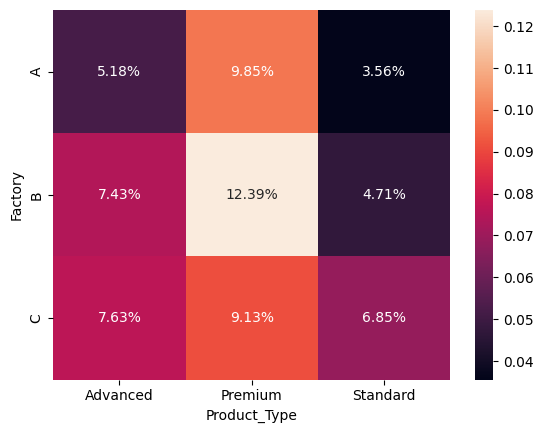

In [8]:
sns.heatmap(pd.pivot_table(
    df,
    index='Factory',
    columns='Product_Type',
    values='Defect',
    aggfunc='mean'
), annot=True, fmt=".2%")

#### 문제 6. 생산 배정 의사결정

Premium 제품 10,000개를 추가 생산해야 한다고 가정합니다.

공장 A, B, C 중 어느 공장에 배정하는 것이 가장 합리적인지 판단하세요.

단, 전체 공장별 불량률만 보지 말고, `Product_Type = Premium` 조건에서의 공장별 불량률을 기준으로 판단하세요.

In [9]:
df.groupby('Factory')['Defect'].mean()

Factory
A    0.047766
B    0.073554
C    0.081502
Name: Defect, dtype: float64

In [11]:
df[df['Product_Type'] == 'Premium'].groupby('Factory')['Defect'].mean().sort_values()

Factory
C    0.091278
A    0.098485
B    0.123894
Name: Defect, dtype: float64

- **<font color="red">AI 코드</font>**

In [15]:
# Premium 제품만 선택
premium_df = df[df["Product_Type"] == "Premium"]

# 공장별 Premium 불량률
result = (
    premium_df.groupby("Factory")["Defect"]
    .agg(["mean", "count", "sum"])
    .reset_index()
)

# 퍼센트 변환
result["defect_rate(%)"] = result["mean"] * 100

print(result)

  Factory      mean  count  sum  defect_rate(%)
0       A  0.098485    132   13        9.848485
1       B  0.123894    226   28       12.389381
2       C  0.091278    493   45        9.127789


#### 문제 7. 해석상 주의점 작성

전체 공장별 불량률만 보고 판단할 때 어떤 오류가 생길 수 있는지 설명하세요.

=> C공장은 전체 불량률이 높지만 Preminum 제품을 많이 생산하며 해당 제품의 불량률은 낮음
